# Print Results

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
import deepinv as dinv
from deepinv.physics import Denoising, GaussianNoise, PoissonNoise
from deepinv.utils.demo import load_url_image, get_image_url
from deepinv.utils.plotting import plot

from opt_functions.plot_results import *
from opt_functions.Solver_functions.white_opt_pnp import *
        
import ISM.simulation.PSF_sim as ism
import ISM.analysis.Graph_lib as gr

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import interact, SelectMultiple
import pandas as pd
import matplotlib.pyplot as plt


device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

Using device: cuda


# GRID SEARCH

In [29]:
def load_result(name, flux, loss, fidelity, save_dir="Results/results_gridsearch"):
    tag = f"Fidelity{fidelity}_{name}_flux{flux}_drunet_loss{loss}"
    return torch.load(os.path.join(save_dir, f"best_rec_{tag}.pth"), weights_only=False)



def plot_psnr_vs_flux(df, losses=None, fidelities=None, save_path=None):
    """losses / fidelities: list of names to show, or None to show all."""
    all_losses = sorted(df["loss"].unique())
    losses = losses or all_losses
    fidelities = fidelities or sorted(df["fidelity"].unique())

    missing = set(losses) - set(all_losses)
    if missing:
        print(f"Not in results: {missing}. Available: {all_losses}")

    sel = df[df["loss"].isin(losses) & df["fidelity"].isin(fidelities)]
    datasets = sorted(sel["data"].unique())
    colors = dict(zip(all_losses, plt.cm.tab10.colors))   # same color per loss in every plot
    styles = {"KL": ("o", "-"), "l2": ("s", "--")}

    fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5),
                             sharey=False, squeeze=False)
    for ax, name in zip(axes[0], datasets):
        for (loss, fid), g in sel[sel["data"] == name].groupby(["loss", "fidelity"]):
            g = g.sort_values("flux")
            marker, ls = styles.get(fid, ("^", ":"))
            ax.plot(g["flux"], g["psnr"], marker=marker, linestyle=ls,
                    color=colors[loss], label=f"{loss} / {fid}")
        ax.set_title(name)
        ax.set_xlabel("flux")
        ax.set_xticks(sorted(sel["flux"].unique()))
        ax.grid(alpha=0.3)

    axes[0][0].set_ylabel("PSNR [dB]")
    axes[0][-1].legend(fontsize=8, ncol=2, title="loss / fidelity")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

def load_result(name, flux, loss, fidelity, prior, save_dir):
    tag = f"Fidelity{fidelity}_{name}_flux{flux}_drunet_{prior}loss{loss}"
    path = os.path.join(save_dir, f"best_rec_{tag}.pth")
    return torch.load(path, weights_only=False) if os.path.exists(path) else None

def load_gt(name):
    x = torch.load(f"Data/Simul_data/{name}.pth", map_location="cpu")
    return (x / x.max()).squeeze().numpy()

def show_grid(name, rows, fluxes, prior, save_dir, crop=None, error=False, save_path=None):
    """
    rows:   list of (loss, fidelity) pairs, one per row, e.g. [("FFL","KL"), ("FFL","l2")]
    fluxes: list of flux values, one per column
    crop:   (y0, y1, x0, x1) to zoom in, or None for the full image
    error:  if True, show |x_rec - x_gt| instead of the reconstruction
    """
    gt = load_gt(name)
    cut = (lambda a: a[crop[0]:crop[1], crop[2]:crop[3]]) if crop else (lambda a: a)

    # load everything first, so the error maps can share one color scale
    recs = {}
    for loss, fid in rows:
        for f in fluxes:
            r = load_result(name, f, loss, fid, prior, save_dir)
            if r is not None:
                img = r["x_rec"].squeeze().numpy()
                recs[(loss, fid, f)] = (img / img.max(), r)
    vmax_err = max((np.abs(cut(im) - cut(gt)).max() for im, _ in recs.values()), default=1)

    n_r, n_c = len(rows), len(fluxes) + 1
    fig, axes = plt.subplots(n_r, n_c, figsize=(2.6 * n_c, 2.6 * n_r), squeeze=False)

    for i, (loss, fid) in enumerate(rows):
        axes[i, 0].imshow(cut(gt), cmap="hot", vmin=0, vmax=1)
        axes[i, 0].set_title("Ground truth" if i == 0 else "", fontsize=9)
        axes[i, 0].set_ylabel(f"{loss}\n{fid}", fontsize=10)

        for j, f in enumerate(fluxes, start=1):
            ax = axes[i, j]
            if (loss, fid, f) not in recs:
                ax.text(0.5, 0.5, "missing", ha="center", va="center", transform=ax.transAxes)
            else:
                im, r = recs[(loss, fid, f)]
                if error:
                    ax.imshow(np.abs(cut(im) - cut(gt)), cmap="inferno", vmin=0, vmax=vmax_err)
                else:
                    ax.imshow(cut(im), cmap="hot", vmin=0, vmax=1)
                ax.set_title(f"flux {f}\n{r['psnr']:.2f} dB  (σ={r['sigma']:.3g}, it={r['iter']})",
                             fontsize=8)

    for ax in axes.flat:
        ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle(f"{name}_notft{'  |  error |x̂ − x|' if error else ''}", fontsize=12)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()




sigma = 0.0077, iter = 100, PSNR = 17.86 dB


KeyError: 'metrics'

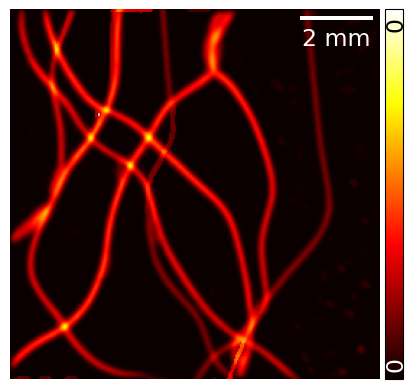

In [33]:
save_dir = "Results/results_gridsearch"

# prior = 'gauss_' # not finetuned
prior = '' # finetuned
pxsizex = 40
Nx = 256
Nz = 1

r = load_result("tub_level", 10, "L2", "KL", prior, save_dir)

print(f"sigma = {r['sigma']:.4f}, iter = {r['iter']}, PSNR = {r['psnr']:.2f} dB")
gr.ShowImg(r["x_rec"], pxsize_x=pxsizex)
dinv.utils.plotting.plot_curves(r["metrics"])

pm = r["psnr_map"].numpy()
plt.imshow(pm, aspect="auto", origin="lower", cmap="viridis")
plt.xticks(range(len(r["iter_grid"])), r["iter_grid"].tolist(), rotation=60)
plt.yticks(range(len(r["sigma_grid"])), [f"{s:.3g}" for s in r["sigma_grid"].tolist()])
plt.xlabel("max_iter"); plt.ylabel("sigma"); plt.colorbar(label="PSNR [dB]")
plt.title(f"{r['name']}, flux {r['flux']}, {r['loss']}, {r['fidelity']}")
plt.show()


df = pd.read_csv("Results/results_gridsearch/summary_notft.csv")

# PSNR table: one row per (data, flux), one column per (loss, fidelity)
table = df.pivot_table(index=["data", "flux"], columns=["loss", "fidelity"], values="psnr")
print(table.round(2))

# Best configuration for each (data, flux)
print(df.loc[df.groupby(["data", "flux"])["psnr"].idxmax()])
# %%

plot_psnr_vs_flux(df, losses=["FFL"])                    # one loss, KL vs l2
plot_psnr_vs_flux(df, losses=["L2"])           # compare two losses
plot_psnr_vs_flux(df, losses=["L1"])
plot_psnr_vs_flux(df, losses=["L1_FFL"])
plot_psnr_vs_flux(df, losses=["L2_FFL"])

fluxes = [5, 10, 20, 40, 60]
losses = ['L2', 'L1', 'FFL', 'L2_FFL', 'L1_FFL']

# 1) All losses with KL, full image
# show_grid("tub_level", [(l, "l2") for l in losses], fluxes)

# 2) Zoom into a detailed region (choose the coordinates by looking at the GT)
# show_grid("tub_level", [(l, "l2") for l in losses], fluxes, crop=(80, 160, 60, 140))

# 3) Same, as error maps: shows where each loss fails
# show_grid("tub_level", [(l, "KL") for l in losses], fluxes, crop=(80, 160, 60, 140), error=True)

# 4) KL vs l2 for a single loss, to isolate the effect of the likelihood
show_grid("tub_balls", [("L2", "KL"), ("L2", "l2")], fluxes, prior, save_dir)

# WHITE PRINCIPLE

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

# 1. Define paths and parameters
mask_type = 'masked' # whole, masked, masked_eps
name_to_load = "tubulin" # tubulin for sim, 05_convallaria / 06_convallaria for real
sect_to_load = "2D" # 3D or 2D
path = f"Results/WP/wp_pnp_{sect_to_load}_{mask_type}_{name_to_load}.pth"

# 2. Load Checkpoint
checkpoint = torch.load(path, weights_only=False)
results = checkpoint['results']
dataset = checkpoint['dataset']
hparams = checkpoint['hparams']

# 3. Extract Grid and Results
sigma_grid = hparams['sigma_grid']
wh_pnp = results['W_sum']

# Calculate knee point (assuming find_knee_point accepts CPU tensors)
best_sigma = find_knee_point(sigma_grid.cpu(), wh_pnp.cpu())
print(f"Best Sigma (Knee Point): {best_sigma.item():.2e}")

# 4. Plot Results
plot_wp_results(
    sigma_grid, 
    results, 
    dataset, 
    hparams['pxsize'], 
    is_real=hparams['IS_REAL'], 
    is_3d=hparams['IS_3D'], 
    title="WP", 
    layout="twin", 
    x0=100, 
    y0=100
)

In [ ]:
def plot_wp_results(sigma_values_grid, results, dataset, pxsize, is_real=False, is_3d=True, title="Metrica", layout="twin", x0=100, y0=100):
    """
    Plotta i risultati dell'ottimizzazione del parametro sigma per PnP.
    """
    W_sum = results["W_sum"]
    results_best = results["results_best"]
    
    # --- FIX DI COMPATIBILITÀ ROBUSTO PER plot_results ---
    if isinstance(results_best, torch.Tensor):
        # Se è un vecchio salvataggio a tensore puro
        x_best = results_best
        results_dict_for_plot = {
            'x_result': x_best, 'funct': None, 'diff_fid': None, 
            'norm2': None, 'iter_err': None, 'psnr': None, 'ssim': None
        }
    else:
        # Copiamo il dizionario per non alterare i dati originali in memoria
        x_best = results_best["x_result"]
        results_dict_for_plot = results_best.copy()
        
        # Rinomina le chiavi generate da RWP_PNP in quelle richieste da plot_results
        if 'iter' in results_dict_for_plot:
            results_dict_for_plot['iter_err'] = results_dict_for_plot.pop('iter')
        if 'psnr_vec' in results_dict_for_plot:
            results_dict_for_plot['psnr'] = results_dict_for_plot.pop('psnr_vec')
        if 'ssim_vec' in results_dict_for_plot:
            results_dict_for_plot['ssim'] = results_dict_for_plot.pop('ssim_vec')
            
        # Se mancano delle chiavi (es. dati reali), le mettiamo a None per evitare KeyError
        required_keys = ['funct', 'diff_fid', 'norm2', 'iter_err', 'psnr', 'ssim']
        for k in required_keys:
            if k not in results_dict_for_plot:
                results_dict_for_plot[k] = None
    # -----------------------------------------------------
    
    # Portiamo tutto su CPU e convertiamo in NumPy per compatibilità perfetta con Matplotlib
    sigma_vals = sigma_values_grid.detach().cpu().numpy()
    W = torch.abs(W_sum).detach().cpu().numpy()
    
    # Calcolo ottimo per WP
    min_idx = np.argmin(W)
    sigma_best_wp = sigma_vals[min_idx]
    
    print(f"--- Risultati per {title} ---")
    print(f"Sigma ottimale (min WP): {sigma_best_wp:.6e} con WP = {W[min_idx]:.6e}")
    
    # Troviamo il knee point usando i tensori su CPU come richiesto dalla funzione originale
    best_sigma_needle = find_knee_point(sigma_values_grid.cpu(), W_sum.cpu()).item()

    # Impostazioni notazione scientifica asse Y
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-1, 1))

    if is_real:
        # --- CASO DATI REALI ---
        plt.figure(figsize=(8, 5))
        
        # Plottiamo W_sum usando i vettori numpy
        plt.semilogx(sigma_vals, W, label="WH", color="tab:blue")
        plt.semilogx(sigma_best_wp, W[min_idx], 'go', label="Minimum")
        
        # Linee verticali
        plt.axvline(sigma_best_wp, color="green", linestyle="--", alpha=0.7)
        plt.axvline(best_sigma_needle, color="red", linestyle="--", alpha=0.7)
        
        # Geometria Knee Point
        x_chord = [sigma_vals[1], sigma_vals[-1]]
        y_chord = [W[1], W[-1]]
        idx_knee = np.argmin(np.abs(sigma_vals - best_sigma_needle))
        y_knee = W[idx_knee]

        plt.plot(x_chord, y_chord, color='gray', linestyle='--', linewidth=1.5, label="Chord")
        
        triangle_x = [sigma_vals[1], sigma_vals[-1], best_sigma_needle]
        triangle_y = [W[1], W[-1], y_knee]
        
        plt.fill(triangle_x, triangle_y, color='orange', alpha=0.2, label="Knee Area")
        plt.plot(triangle_x + [triangle_x[0]], triangle_y + [triangle_y[0]], 
                 color='darkorange', linestyle='-', linewidth=1)
        plt.plot(best_sigma_needle, y_knee, 'ro', markersize=8, label="Knee Point")

        # Formattazione assi (Senza "set_")
        plt.gca().yaxis.set_major_formatter(formatter)
        plt.xlabel("Sigma", fontsize=14)
        plt.ylabel(r"$\mathrm{KL}(x_k,\ x_{\mathrm{GT}})$", fontsize=14)
        plt.title(f"{title} Real Data")
        
        plt.grid(True)
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()
        
    else:
        # --- CASO DATI SIMULATI ---
        psnr = results["psnr_vecs"].detach().cpu().numpy()
        ssim = results["ssim_vecs"].detach().cpu().numpy()
        max_idx_psnr = np.argmax(psnr)
        max_idx_ssim = np.argmax(ssim)
        
        print(f"Sigma ottimale (max PSNR): {sigma_vals[max_idx_psnr]:.6e} con PSNR = {psnr[max_idx_psnr]:.4f} dB")
        print(f"Sigma ottimale (max SSIM): {sigma_vals[max_idx_ssim]:.6e} con SSIM = {ssim[max_idx_ssim]:.4f}\n")

        if layout == "twin":
            fig, ax1 = plt.subplots(figsize=(8, 5))

            ax1.semilogx(sigma_vals, W, label="WH", color="tab:blue")
            ax1.semilogx(sigma_best_wp, W[min_idx], 'go')
            ax1.yaxis.set_major_formatter(formatter)
            
            # Applichiamo xlabel e ylabel all'asse principale (plt)
            plt.xlabel("Sigma", fontsize=14)
            plt.ylabel(r"$\mathrm{KL}(x_k,\ x_{\mathrm{GT}})$", fontsize=14)
            
            ax1.tick_params(axis='y', labelcolor="tab:blue")
            ax1.axvline(sigma_best_wp, color="green", linestyle="--", alpha=0.7)

            # Asse secondario per PSNR
            ax2 = ax1.twinx()
            ax2.semilogx(sigma_vals, psnr, label="PSNR", color="tab:orange")
            ax2.semilogx(sigma_vals[max_idx_psnr], psnr[max_idx_psnr], 'ro')
            ax2.set_ylabel("PSNR (dB)", color="tab:orange")
            ax2.tick_params(axis='y', labelcolor="tab:orange")
            ax2.axvline(sigma_vals[max_idx_psnr], color="red", linestyle="--", alpha=0.7)

            # Combina le legende
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

            plt.title("WH")
            plt.grid(True)
            plt.tight_layout()
            plt.show()

        elif layout == "stacked":
            fig, axs = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

            # WH Loss
            axs[0].semilogx(sigma_vals, W, color="tab:blue")
            axs[0].semilogx(sigma_best_wp, W[min_idx], 'go')
            axs[0].axvline(sigma_best_wp, color="green", linestyle="--")
            axs[0].axvline(best_sigma_needle, color="orange", linestyle="--", alpha=0.7)
            axs[0].yaxis.set_major_formatter(formatter)
            axs[0].set_ylabel(r"$\mathrm{KL}(x_k,\ x_{\mathrm{GT}})$", fontsize=12)
            axs[0].grid(True)

            # PSNR
            axs[1].semilogx(sigma_vals, psnr, color="tab:orange")
            axs[1].semilogx(sigma_vals[max_idx_psnr], psnr[max_idx_psnr], 'ro')
            axs[1].axvline(sigma_vals[max_idx_psnr], color="red", linestyle="--")
            axs[1].axvline(best_sigma_needle, color="orange", linestyle="--", alpha=0.7)
            axs[1].set_ylabel("PSNR (dB)")
            axs[1].grid(True)

            # SSIM
            axs[2].semilogx(sigma_vals, ssim, color="tab:green")
            axs[2].semilogx(sigma_vals[max_idx_ssim], ssim[max_idx_ssim], 'go')
            axs[2].axvline(sigma_vals[max_idx_ssim], color="green", linestyle="--")
            axs[2].axvline(best_sigma_needle, color="orange", linestyle="--", alpha=0.7)
            axs[2].set_ylabel("SSIM")
            axs[2].grid(True)
            
            # Applichiamo xlabel globale
            plt.xlabel("Sigma", fontsize=14)
            plt.suptitle("WH")
            
            plt.tight_layout()
            plt.show()
                       
    # Assumendo che plot_results sia definita altrove nel tuo codice
    # CORRETTO: passi il dizionario che abbiamo appena "patchato" con i nomi giusti
    plot_results(results_dict_for_plot, dataset, is_real, is_3d, pxsize, x0_sec=x0, y0_sec=y0)

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

# 1. Define paths and parameters
mask_type = 'masked' # whole, masked, masked_eps
name_to_load = "tubulin" # tubulin for sim, 05_convallaria / 06_convallaria for real
sect_to_load = "2D" # 3D or 2D
path = f"Results/WP/wp_pnp_{sect_to_load}_{mask_type}_{name_to_load}.pth"

# 2. Load Checkpoint
checkpoint = torch.load(path, weights_only=False)
results_to_save = checkpoint['results']
dataset = checkpoint['dataset']
hparams = checkpoint['hparams']

# 3. Extract Global Variables
sigma_grid = hparams['sigma_grid']
# Fallback to the default list if it wasn't saved in hparams
iter_values_grid = hparams.get('iter_values_grid', [200, 400, 600, 800, 1000])

# --- CRITICAL FIX: Extract the nested dictionary ---
iterations_data = results_to_save['iterations_data']

# 4. Loop over each iteration value and generate its plot
for iter_num in iter_values_grid:
    # Failsafe in case a specific iteration didn't save properly
    if iter_num not in iterations_data:
        print(f"Skipping iter {iter_num} - not found in data.")
        continue
        
    print(f"\n{'='*40}")
    print(f"PLOTTING RESULTS FOR MAX_ITER = {iter_num}")
    print(f"{'='*40}")
    
    # Isolate the results for this specific iteration count
    current_results = iterations_data[iter_num]
    
    # NOW we can safely extract W_sum
    wh_pnp = current_results['W_sum']

    # Calculate knee point
    best_sigma = find_knee_point(sigma_grid.cpu(), wh_pnp.cpu())
    print(f"Best Sigma (Knee Point): {best_sigma.item():.2e}")

    # Dynamic title so you know which plot you are looking at
    plot_title = f"WH (Max Iters: {iter_num})"
    
    # 5. Plot Results
    plot_wp_results(
        sigma_grid, 
        current_results,  # Pass the isolated results dict for this iteration
        dataset, 
        hparams['pxsize'], 
        is_real=hparams['IS_REAL'], 
        is_3d=hparams['IS_3D'], 
        title=plot_title, 
        layout="twin", 
        x0=100, 
        y0=100
    )

In [ ]:
real_name = 'tubulin'
IS_REAL = False
IS_3D = True

if IS_3D and real_name == 'tubulin':
    list_methods = [("pgd", 0.0134), ("prox", 0.0268), ("md", 0.309),("md_l1", 0.0604),  ('rl', 0)]
elif not IS_3D and real_name == 'tubulin':
    list_methods = [("pgd", 0.00672), ("prox", 0.0805), ("md", 0.0537), ("md_l1", 0.0805), ('rl', 0)]


    
if IS_REAL and real_name == '01_tomm20':
    list_methods = [("pgd", 0.0111), ("prox", 0.0243), ("md", 0.00304), ("md_l1", 0.00708),('rl', 0)]
    
elif IS_REAL and real_name == '02_tomm20':
    list_methods = [("pgd", 0.0354), ("prox", 0.0556), ("md", 0.0485), ("md_l1", 0.00672),('rl', 0)]

elif IS_REAL and real_name == '03_tomm20':
    list_methods = [("pgd", 0.00708), ("prox", 0.0394), ("md", 0.0485), ("md_l1", 0.00672),('rl', 0)]
    
elif IS_REAL and real_name == '04_tomm20':
    list_methods = [("pgd", 0.00708), ("prox", 0.0253), ("md", 0.00102), ("md_l1",0.0738 ),('rl', 0)]
    

# --- CONFIGURAZIONE ---
mask_type = 'masked'
name_to_load = real_name
sect_to_load = "3D" if IS_3D else '2D'  # "2D" o "3D"
real_to_load = "sim" if real_name == 'tubulin' else 'real'



# Dizionario dove salveremo i tensori caricati
loaded_results = {}

# --- CARICAMENTO NO-REG (Baseline) ---
# Di solito serve come riferimento, lo carichiamo separatamente
path_noreg = f"Results/ism_results/ism_{sect_to_load}_{real_to_load}_pgd_{name_to_load}_lam0.pth"
checkpoint_noreg = torch.load(path_noreg, weights_only=False)
x_result_noreg = checkpoint_noreg['results']['x_result'].cpu()
noise_image = checkpoint_noreg['dataset']["noise_image"].cpu()
dataset = checkpoint_noreg['dataset'] # Salviamo il dataset per i plot
hparams = checkpoint_noreg['hparams']

# --- LOOP CARICAMENTO AUTOMATICO ---
for algo, lam in list_methods:
    
    # 1. Gestione casi particolari del percorso
    if algo == "md_l1":
        # Nota: nel tuo codice md_l1 usa algo="md" nel path ma ha il prefisso "ism_l1_"
        filename = f"ism_l1_{sect_to_load}_{real_to_load}_md_{name_to_load}_lam{lam}.pth"
        key_name = "mdl1"
        
    elif algo == "rl":
        # Per RL carichiamo entrambi i file (500 e 1000)
        for iters in [500, 1000]:
            path_rl = f"Results/ism_results/ism_{sect_to_load}_{real_to_load}_rl_{name_to_load}_lam0_iter{iters}.pth"
            try:
                ckpt = torch.load(path_rl, weights_only=False)
                loaded_results[f"rl{iters}"] = ckpt['results']['x_result'].cpu()
            except FileNotFoundError:
                print(f"File non trovato: {path_rl}")
        continue # Salta il caricamento standard per RL
        
    else:
        filename = f"ism_{sect_to_load}_{real_to_load}_{algo}_{name_to_load}_lam{lam}.pth"
        # Mappa i nomi degli algoritmi alle tue chiavi preferite
        key_mapping = {"pgd": "tv", "prox": "l1", "md": "mdtv"}
        key_name = key_mapping.get(algo, algo)

    # 2. Caricamento effettivo
    path = f"Results/ism_results/{filename}"
    try:
        checkpoint = torch.load(path, weights_only=False)
        loaded_results[key_name] = checkpoint['results']['x_result'].cpu()
        print(f"Caricato: {key_name} da {filename}")
    except FileNotFoundError:
        print(f"Errore: File non trovato {path}")

# --- ASSEGNAZIONE VARIABILI (Per compatibilità con i tuoi script di plot) ---
x_result_tv     = loaded_results.get('tv')
x_result_l1     = loaded_results.get('l1')
x_result_mdtv   = loaded_results.get('mdtv')
x_result_mdl1   = loaded_results.get('mdl1')
x_result_rl500 = loaded_results.get('rl500')
x_result_rl1000  = loaded_results.get('rl1000')

In [ ]:
grid = ism.GridParameters()
grid.N = 5              # number of detector elements in each dimension
grid.pxsizex = hparams['pxsize']      # pixel size of the simulation space (nm)
grid.pxdim = 50e3       # detector element size in real space (nm)
grid.pxpitch = 75e3     # detector element pitch in real space (nm)
grid.M = 500            # total magnification of the optical system (e.g. 100x objective followed by 5x telescope)
grid.Nz = hparams['Nz']
grid.pxsizez = 700
exPar = ism.simSettings()
exPar.wl = 640 # excitation wavelength (nm)
exPar.mask_sampl = 31
emPar = exPar.copy()
emPar.wl = 660 # emission wavelength (nm)
z_shift = 0 #nm

# 4 righe x 3 colonne
fig, ax = plt.subplots(4, 4, sharex='row', sharey='row', figsize=(10, 13))

x0 = 40
y0 = 50
dx = 100
dy = 100

def get_rect():
    return patches.Rectangle((y0, x0), dy, dx, linewidth=1, edgecolor='w', facecolor='none')

# Nota: Assicurati di aver creato la griglia con 4 colonne:
# fig, ax = plt.subplots(4, 4, figsize=(...))

# ==========================================
# --- PARTE SUPERIORE (Righe 0 e 1) ---
# ==========================================

# --- 1. Top Col 0: Noise ---
gr.ShowImg(noise_image[:,:,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[0,0])
gr.ShowImg(noise_image[:,:,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[1,0])
ax[0,0].add_patch(get_rect()); ax[0,0].set_title("Noise image sum")

# --- 2. Top Col 1: No Regularization ---
gr.ShowImg(x_result_noreg[:,:,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[0,1])
gr.ShowImg(x_result_noreg[:,:,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[1,1])
ax[0,1].add_patch(get_rect()); ax[0,1].set_title("No Regularization")

# --- 3. Top Col 2: PGD (TV) ---
gr.ShowImg(x_result_tv[:,:,:, :], grid.pxsizex*1e-3, fig=fig, ax=ax[0,2])
gr.ShowImg(x_result_tv[:,:,x0:x0+dx, y0:y0+dx], grid.pxsizex*1e-3, fig=fig, ax=ax[1,2])
ax[0,2].add_patch(get_rect()); ax[0,2].set_title("PGD TV")

# --- 4. Top Col 3: RL 1000 (NUOVO) ---
gr.ShowImg(x_result_rl500[:,:,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[0,3])
gr.ShowImg(x_result_rl500[:,:,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[1,3])
ax[0,3].add_patch(get_rect()); ax[0,3].set_title("RL 1000")


# ==========================================
# --- PARTE INFERIORE (Righe 2 e 3) ---
# ==========================================

# --- 5. Bottom Col 0: PROX (L1) ---
gr.ShowImg(x_result_l1[:,:,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[2,0])
gr.ShowImg(x_result_l1[:,:,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[3,0])
ax[2,0].add_patch(get_rect()); ax[2,0].set_title("PROX L1")

# --- 6. Bottom Col 1: Mirror Descent (MD TV) ---
gr.ShowImg(x_result_mdtv[:,:,:, :], grid.pxsizex*1e-3, fig=fig, ax=ax[2,1])
gr.ShowImg(x_result_mdtv[:,:,x0:x0+dx, y0:y0+dx], grid.pxsizex*1e-3, fig=fig, ax=ax[3,1])
ax[2,1].add_patch(get_rect()); ax[2,1].set_title("MD TV")

# --- 7. Bottom Col 2: Mirror Descent (MD L1) ---
# Qui ho corretto la variabile da mdtv a mdl1 (assumendo che esista)
gr.ShowImg(x_result_mdl1[:,:,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[2,2])
gr.ShowImg(x_result_mdl1[:,:,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[3,2])
ax[2,2].add_patch(get_rect()); ax[2,2].set_title("MD L1")

# --- 8. Bottom Col 3: RL 500 (NUOVO) ---
gr.ShowImg(x_result_rl1000[:,:,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[2,3])
gr.ShowImg(x_result_rl1000[:,:,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[3,3])
ax[2,3].add_patch(get_rect()); ax[2,3].set_title("RL 500")

fig.tight_layout()

In [ ]:
grid = ism.GridParameters()
grid.N = 5              # number of detector elements in each dimension
grid.pxsizex = hparams['pxsize']      # pixel size of the simulation space (nm)
grid.pxdim = 50e3       # detector element size in real space (nm)
grid.pxpitch = 75e3     # detector element pitch in real space (nm)
grid.M = 500            # total magnification of the optical system (e.g. 100x objective followed by 5x telescope)
grid.Nz = hparams['Nz']
grid.pxsizez = 700
exPar = ism.simSettings()
exPar.wl = 640 # excitation wavelength (nm)
exPar.mask_sampl = 31
emPar = exPar.copy()
emPar.wl = 660 # emission wavelength (nm)
z_shift = 0 #nm

# 4 righe x 3 colonne
fig, ax = plt.subplots(4, 4, sharex='row', sharey='row', figsize=(10, 13))

x0 = 40
y0 = 50
dx = 100
dy = 100

def get_rect():
    return patches.Rectangle((y0, x0), dy, dx, linewidth=1, edgecolor='w', facecolor='none')

# Nota: Assicurati di aver creato la griglia con 4 colonne:
# fig, ax = plt.subplots(4, 4, figsize=(...))

# ==========================================
# --- PARTE SUPERIORE (Righe 0 e 1) ---
# ==========================================

# --- 1. Top Col 0: Noise ---
gr.ShowImg(noise_image[:,:,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[0,0])
gr.ShowImg(noise_image[:,:,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[1,0])
ax[0,0].add_patch(get_rect()); ax[0,0].set_title("Noise image sum")

# --- 2. Top Col 1: No Regularization ---
gr.ShowImg(x_result_noreg[:,1:2,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[0,1])
gr.ShowImg(x_result_noreg[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[1,1])
ax[0,1].add_patch(get_rect()); ax[0,1].set_title("No Regularization")

# --- 3. Top Col 2: PGD (TV) ---
gr.ShowImg(x_result_tv[:,1:2,:, :], grid.pxsizex*1e-3, fig=fig, ax=ax[0,2])
gr.ShowImg(x_result_tv[:,1:2,x0:x0+dx, y0:y0+dx], grid.pxsizex*1e-3, fig=fig, ax=ax[1,2])
ax[0,2].add_patch(get_rect()); ax[0,2].set_title("PGD TV")

# --- 4. Top Col 3: RL 1000 (NUOVO) ---
gr.ShowImg(x_result_rl500[:,1:2,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[0,3])
gr.ShowImg(x_result_rl500[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[1,3])
ax[0,3].add_patch(get_rect()); ax[0,3].set_title("RL 1000")


# ==========================================
# --- PARTE INFERIORE (Righe 2 e 3) ---
# ==========================================

# --- 5. Bottom Col 0: PROX (L1) ---
gr.ShowImg(x_result_l1[:,1:2,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[2,0])
gr.ShowImg(x_result_l1[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[3,0])
ax[2,0].add_patch(get_rect()); ax[2,0].set_title("PROX L1")

# --- 6. Bottom Col 1: Mirror Descent (MD TV) ---
gr.ShowImg(x_result_mdtv[:,1:2,:, :], grid.pxsizex*1e-3, fig=fig, ax=ax[2,1])
gr.ShowImg(x_result_mdtv[:,1:2,x0:x0+dx, y0:y0+dx], grid.pxsizex*1e-3, fig=fig, ax=ax[3,1])
ax[2,1].add_patch(get_rect()); ax[2,1].set_title("MD TV")

# --- 7. Bottom Col 2: Mirror Descent (MD L1) ---
# Qui ho corretto la variabile da mdtv a mdl1 (assumendo che esista)
gr.ShowImg(x_result_mdl1[:,1:2,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[2,2])
gr.ShowImg(x_result_mdl1[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[3,2])
ax[2,2].add_patch(get_rect()); ax[2,2].set_title("MD L1")

# --- 8. Bottom Col 3: RL 500 (NUOVO) ---
gr.ShowImg(x_result_rl1000[:,1:2,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[2,3])
gr.ShowImg(x_result_rl1000[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[3,3])
ax[2,3].add_patch(get_rect()); ax[2,3].set_title("RL 500")

fig.tight_layout()

In [ ]:
# Definiamo una lista di configurazioni aggiornata
sec = "3D"
tasks = [
    # --- RIGA 0 & 1: Baseline (Noise, NoReg, PGD TV) ---
    (noise_image.sum(0), f"{name_to_load}_{sec}_noise_full"),
    (x_result_noreg[:,1:2,:, :].sum(0), f"{name_to_load}_{sec}_noreg_full"),
    (x_result_tv[:,1:2,:, :], f"{name_to_load}_{sec}_pgd_tv_full"),
    
    (noise_image[:,:,x0:x0+dx, y0:y0+dx].sum(0), f"{name_to_load}_{sec}_noise_crop"),
    (x_result_noreg[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), f"{name_to_load}_{sec}_noreg_crop"),
    (x_result_tv[:,1:2,x0:x0+dx, y0:y0+dx], f"{name_to_load}_{sec}_pgd_tv_crop"),
    
    # --- RIGA 2 & 3: Standard Reg (Prox L1, MD TV, MD L1) ---
    (x_result_l1[:,1:2,:, :].sum(0), f"{name_to_load}_{sec}_prox_l1_full"),
    (x_result_mdtv[:,1:2,:, :], f"{name_to_load}_{sec}_md_tv_full"),
    (x_result_mdl1[:,1:2,:, :].sum(0), f"{name_to_load}_{sec}_md_l1_full"),
    
    (x_result_l1[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), f"{name_to_load}_{sec}_prox_l1_crop"),
    (x_result_mdtv[:,1:2,x0:x0+dx, y0:y0+dx], f"{name_to_load}_{sec}_md_tv_crop"),
    (x_result_mdl1[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), f"{name_to_load}_{sec}_md_l1_crop"),

    # --- NUOVI: RL 1000 ---
    (x_result_rl1000[:,1:2,:, :].sum(0), f"{name_to_load}_{sec}_rl1000_full"),
    (x_result_rl1000[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), f"{name_to_load}_{sec}_rl1000_crop"),

    # --- NUOVI: RL 500 ---
    (x_result_rl500[:,1:2,:, :].sum(0), f"{name_to_load}_{sec}_rl100_full"),
    (x_result_rl500[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), f"{name_to_load}_{sec}_rl100_crop")
]

for data, name in tasks:
    print(f"Processando: {name}")
    
    # 1. Visualizzazione
    fig, ax = gr.ShowImg(data, grid.pxsizex*1e-3)
    
    # 2. Rettangolo per il crop (opzionale, commentato come nel tuo originale)
    if "full" in name:
        rect = patches.Rectangle((y0, x0), dy, dx, linewidth=1, edgecolor='w', facecolor='none')
        ax.add_patch(rect)
    
    # 3. Salvataggio in PDF
    # Cambiato da .eps a .pdf
    output_name = f"{name}.pdf" 
    
    # Cambiato format='eps' a format='pdf'
    # Manteniamo dpi=300 e bbox_inches='tight' per la massima qualità
    fig.savefig(output_name, format='pdf', bbox_inches='tight', dpi=300)
    
    # 4. Cleanup
    plt.close(fig)
    print(f"Salvato con successo: {output_name}")

In [ ]:
name = "gt_tub2d"
data = dataset['ground_truth']
print(f"Processando: {name}")

# 1. Visualizzazione
fig, ax = gr.ShowImg(data, grid.pxsizex*1e-3)

# 2. Rettangolo per il crop (opzionale, commentato come nel tuo originale)
# if "full" in name:
#     rect = patches.Rectangle((y0, x0), dy, dx, linewidth=1, edgecolor='w', facecolor='none')
#     ax.add_patch(rect)

# 3. Salvataggio in PDF
# Cambiato da .eps a .pdf
output_name = f"{name}.pdf" 

# Cambiato format='eps' a format='pdf'
# Manteniamo dpi=300 e bbox_inches='tight' per la massima qualità
fig.savefig(output_name, format='pdf', bbox_inches='tight', dpi=300)

# 4. Cleanup
plt.close(fig)
print(f"Salvato con successo: {output_name}")

# OPTIM WP

In [ ]:
# path = "Results/WP/wp_3D_pgd_masked_06_convallaria.pth"
mask_type = 'masked'                 # whole, masked, masked_eps
algo_to_load = "pgd"                # pgd or prox or md
name_to_load = "02_tomm20"     # tubulin for sim
sect_to_load = "3D"                 # 3D or 2D

path = f"Results/WP/wp_optim_{sect_to_load}_{algo_to_load}_{mask_type}_{name_to_load}.pth"


checkpoint = torch.load(path, weights_only = False)
results = checkpoint['results_optim']
best_result = results['results_best']
dataset = checkpoint['dataset']
hparams = checkpoint['hparams']


print(f" Miglior mu trovato: {results['best_mu']:.6f} con RWP = {results['rwp_vec'].min():.4f}")

plt.plot(results['rwp_vec'][100:].cpu())

plot_results(best_result, dataset, hparams['IS_REAL'], hparams['IS_3D'], hparams['pxsize'], x0_sec = 100, y0_sec = 100)


In [ ]:
import subprocess
from pathlib import Path

def converti_veloce():
    input_dir = Path("Images_eps")
    output_dir = Path("Images_pdf")
    output_dir.mkdir(exist_ok=True)

    for eps_file in input_dir.glob("*.eps"):
        pdf_file = output_dir / (eps_file.stem + ".pdf")
        try:
            # shell=True permette di usare i comandi di sistema direttamente
            subprocess.run(["epstopdf", str(eps_file), f"--outfile={str(pdf_file)}"], check=True)
            print(f"✅ {eps_file.name} convertito.")
        except Exception as e:
            print(f"❌ Errore su {eps_file.name}: {e}")

converti_veloce()

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# 1. Imposta il percorso del file salvato
# Assicurati che il percorso sia corretto rispetto alla posizione del notebook
file_path = Path("Results/Experiment_Flux_MultiRealization/experiment_avg_pgd.pth")

if not file_path.exists():
    print(f"Errore: Il file {file_path} non esiste. Controlla il percorso!")
else:
    # 2. Carica i dati
    history = torch.load(file_path)

    # Estraiamo i valori (convertendoli in liste se sono tensori)
    # 2. Carica i dati
    history = torch.load(file_path)


    # Convertiamo le liste in tensori, spostiamoli su CPU e trasformiamoli in Numpy per il plot
    # Usiamo torch.as_tensor() perché è efficiente
    flux = torch.as_tensor(history['flux']).cpu().numpy()
    psnr = torch.as_tensor(history['psnr_mean']).cpu().numpy()
    ssim = torch.as_tensor(history['ssim_mean']).cpu().numpy()
    lambdas = torch.as_tensor(history['best_mu_mean']).cpu().numpy()

    # Prepariamo la figura con 3 grafici
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    plt.subplots_adjust(wspace=0.3)

    # --- Grafico 1: PSNR vs Flux ---
    # Ora flux e psnr sono array Numpy, Matplotlib li adora
    axs[0].plot(flux, psnr, 'o-', color='tab:blue', linewidth=2, markersize=8)
    # ... resto del codice invariato ...

    # Prepariamo la figura con 3 grafici
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    plt.subplots_adjust(wspace=0.3)

    # --- Grafico 1: PSNR vs Flux ---
    axs[0].plot(flux, psnr, 'o-', color='tab:blue', linewidth=2, markersize=8)
    axs[0].set_xlabel('Flux (Photon Count)', fontsize=12)
    axs[0].set_ylabel('PSNR (dB)', fontsize=12)
    axs[0].set_title('Reconstruction Quality: PSNR', fontsize=14, fontweight='bold')
    axs[0].grid(True, linestyle='--', alpha=0.7)

    # --- Grafico 2: SSIM vs Flux ---
    axs[1].plot(flux, ssim, 's-', color='tab:red', linewidth=2, markersize=8)
    axs[1].set_xlabel('Flux (Photon Count)', fontsize=12)
    axs[1].set_ylabel('SSIM', fontsize=12)
    axs[1].set_title('Structural Similarity: SSIM', fontsize=14, fontweight='bold')
    axs[1].grid(True, linestyle='--', alpha=0.7)

    # --- Grafico 3: Lambda (Best Mu) vs Flux ---
    axs[2].plot(flux, lambdas, '^--', color='tab:green', linewidth=2, markersize=8)
    axs[2].set_xlabel('Flux (Photon Count)', fontsize=12)
    axs[2].set_ylabel(r'Optimal $\lambda$ ($\mu$)', fontsize=12)
    axs[2].set_title('Regularization Parameter $\lambda$', fontsize=14, fontweight='bold')
    axs[2].grid(True, linestyle='--', alpha=0.7)
    # Spesso lambda varia di ordini di grandezza, se necessario scommenta la riga sotto:
    # axs[2].set_yscale('log') 

    plt.suptitle('Experiment Results: Flux Impact on s2ISM Reconstruction', fontsize=16, y=1.05)
    
    # Salva il riepilogo in PDF
    plt.savefig(file_path.parent / "summary_plots.pdf", bbox_inches='tight')
    plt.show()

    # 3. Stampa una tabella veloce dei valori
    print(f"{'Flux':<10} | {'PSNR':<10} | {'SSIM':<10} | {'Best Lambda':<10}")
    print("-" * 50)
    for f, p, s, l in zip(flux, psnr, ssim, lambdas):
        print(f"{f:<10} | {p:<10.2f} | {s:<10.4f} | {l:<10.2e}")
        
    
        
# for i in range(len(history['results'])):
#     plot(history['results'][i]['results_best']['x_result'], cmap = 'hot', subtitles= f'flux = {history["flux"][i]}')


In [ ]:
print(history.keys())


In [ ]:
i = 0
print(history['flux'][i])
print(history['best_mu_mean'][i])

print(history['raw_data'][i]['mu_all'])
